# 06 — Extra Analyses

Analyses that support claims in the manuscript but aren't part of the main pipeline (01 → 05): whether cohorts differ in clinical severity (MoCA/UPDRS), the BIC-based automatic choice of `k` versus the exhaustive-search value actually used, and a quick data-quality check on how much of each recording is blink.


## MoCA / UPDRS Cohort Comparison

Checks whether the PD, control, and young-control cohorts differ in cognitive (MoCA) or motor (UPDRS) severity -- relevant to whether gaze differences between cohorts could be a cognitive-decline confound rather than a PD-specific effect.

In [1]:
import os
import pickle
import itertools

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
%matplotlib inline

dir_pkls = "../pkls/basic/"
dir_media = "../../../media/"

with open(os.path.join(dir_pkls, 'group_labels.pkl'), 'rb') as f:
    group_labels = pickle.load(f)

moca_results = pd.read_csv(os.path.join(dir_media, 'MOCA_results.txt'), sep=";")
updrs_results = pd.read_csv(os.path.join(dir_media, 'UPDRS_results.txt'), sep=";")
updrs_results['CODIGO_PACIENTE'] = updrs_results['CODIGO_PACIENTE'].astype(str).str.strip()
id_patient_moca = pd.read_csv(os.path.join(dir_media, 'ID_paciente.txt'), sep=";")


In [2]:
# UPDRS with groups (healthy, PD)
updrs_with_group = pd.merge(updrs_results, group_labels, left_on='CODIGO_PACIENTE', right_on='patient_id')

# MoCA with groups: join moca_results -> id_patient_moca (patient IDs) -> group_labels
moca_with_id = pd.merge(moca_results, id_patient_moca, left_on='ID_HISTORIAL_MOCA', right_on='ID_HISTORIAL_PACIENTE')
moca_with_id = moca_with_id[moca_with_id['ID_NUMVISITA_MOCA'] == 1]  # first visit only
moca_with_id['CODIGO_PACIENTE'] = moca_with_id['CODIGO_PACIENTE'].str.strip()
moca_with_id = moca_with_id[moca_with_id['CODIGO_PACIENTE'] != 'HG044']  # MSA diagnosis, excluded throughout

moca_with_group = pd.merge(moca_with_id, group_labels, left_on='CODIGO_PACIENTE', right_on='patient_id')


In [3]:
# Mean/SD of UPDRS and MoCA per cohort
print("UPDRS by cohort:")
display(updrs_with_group.groupby('group')['RESULT_UPDRS'].agg(['mean', 'std']).reset_index())

print("\nMoCA by cohort:")
display(moca_with_group.groupby('group')['RES_MOCA'].agg(['mean', 'std']).reset_index())


UPDRS by cohort:


,group,mean,std
0,PD,17.011236,10.498370
1,control,1.376471,9.990444
2,young control,0.000000,0.000000



MoCA by cohort:


,group,mean,std
0,PD,25.163265,4.408075
1,control,26.745098,2.496743
2,young control,28.789474,1.436777


In [4]:
# Pairwise Welch t-tests, UPDRS and MoCA
def pairwise_welch_ttests(df, value_col, group_col='group'):
    groups = df[group_col].unique()
    results = []
    for g1, g2 in itertools.combinations(groups, 2):
        scores1 = df.loc[df[group_col] == g1, value_col]
        scores2 = df.loc[df[group_col] == g2, value_col]
        t_stat, p_val = ttest_ind(scores1, scores2, equal_var=False)
        results.append({'group1': g1, 'group2': g2, 't_statistic': t_stat, 'p_value': p_val})
    return pd.DataFrame(results)

print("UPDRS pairwise comparisons:")
display(pairwise_welch_ttests(updrs_with_group, 'RESULT_UPDRS'))

print("\nMoCA pairwise comparisons:")
display(pairwise_welch_ttests(moca_with_group, 'RES_MOCA'))


UPDRS pairwise comparisons:


,group1,group2,t_statistic,p_value
0,control,PD,-10.065804,4.972572e-19
1,control,young control,1.270257,2.075003e-01
2,PD,young control,15.286532,1.685626e-26



MoCA pairwise comparisons:


,group1,group2,t_statistic,p_value
0,control,PD,2.196178,0.031159
1,control,young control,-4.254698,0.000081
2,PD,young control,-5.101761,0.000003


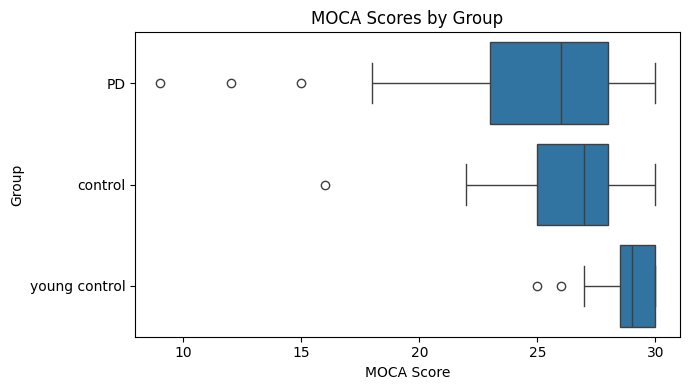

In [5]:
plt.figure(figsize=(7, 4))
sns.boxplot(y='group', x='RES_MOCA', data=moca_with_group, order=['PD', 'control', 'young control'])
plt.title('MOCA Scores by Group')
plt.ylabel('Group')
plt.xlabel('MOCA Score')
plt.tight_layout()
plt.show()


## BIC-Based Automatic Choice of *k* vs. Exhaustive Search

The manuscript considers BIC as an automatic alternative to exhaustive search (ES) for choosing the number of GMM components `k`, but reports it yielded consistently lower classification performance and was not retained. This reproduces the BIC elbow detection (the method described in the paper: the point where the slope of the smoothed BIC curve approaches -1) and compares the resulting `k` against the ES-chosen `k` actually used in the pipeline.


In [6]:
import numpy as np

with open('../pkls/metrics/bic_scores_dict.pkl', 'rb') as f:
    bic_scores = pickle.load(f)

k_values = np.arange(5, 51)  # 5 to 50 inclusive

raw_color = '#556B2F'
smooth_color = '#556B2F80'
tangent_color = '#D62728'
vline_color = '#BBBBBB'

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

def smooth_curve(y, window=5):
    return np.convolve(y, np.ones(window) / window, mode='valid')

def compute_slope(x, y):
    return np.diff(y) / np.diff(x)

def find_elbow_k_real_units(x, y, window=5, slope_target=-1.0):
    x_norm = normalize(x)
    y_norm = normalize(y)
    y_smooth_norm = smooth_curve(y_norm, window=window)
    x_smooth = x[(window // 2):-(window // 2) or None]
    slope = compute_slope(x_norm[(window // 2):-(window // 2) or None], y_smooth_norm)
    x_centered = x_smooth[1:]
    idx = np.argmin(np.abs(slope - slope_target))
    return x_centered[idx], slope[idx]


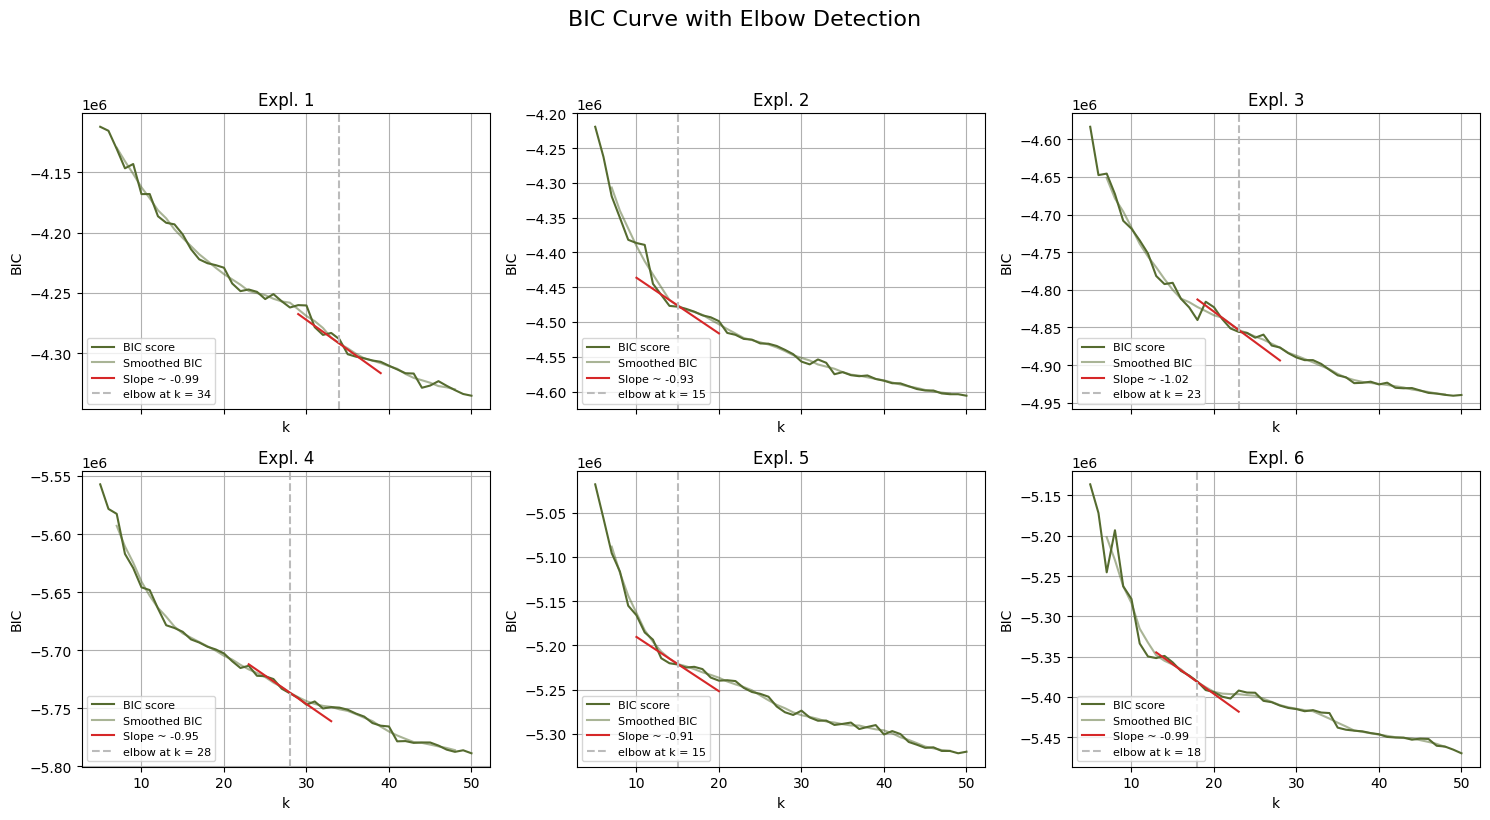

,exploration,k_clusters_bic
0,Exploration_1,34
1,Exploration_2,15
2,Exploration_3,23
3,Exploration_4,28
4,Exploration_5,15
5,Exploration_6,18


In [7]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axs = axs.flatten()

elbow_dict = {}

for i in range(6):
    key = f"Exploration_{i+1}"
    x = k_values
    y = np.array(bic_scores[key])

    k_elbow, slope_val = find_elbow_k_real_units(x, y)
    elbow_dict[key] = int(round(k_elbow))

    y_smooth = smooth_curve(y, window=5)
    x_smooth = x[(5 // 2):-(5 // 2) or None]

    ax = axs[i]
    ax.plot(x, y, color=raw_color, label='BIC score')
    ax.plot(x_smooth, y_smooth, color=smooth_color, label='Smoothed BIC')

    x0 = k_elbow
    y0 = np.interp(x0, x_smooth, y_smooth)
    x_tangent = np.array([x0 - 5, x0 + 5])
    real_slope = slope_val * ((np.max(y) - np.min(y)) / (np.max(x) - np.min(x)))
    y_tangent = y0 + real_slope * (x_tangent - x0)
    ax.plot(x_tangent, y_tangent, linestyle='-', color=tangent_color, label=f"Slope ~ {slope_val:.2f}")
    ax.axvline(k_elbow, color=vline_color, linestyle='--', label=f"elbow at k = {int(round(k_elbow))}")

    ax.set_title(f"Expl. {i+1}")
    ax.set_xlabel("k")
    ax.set_ylabel("BIC")
    ax.grid(True)
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle("BIC Curve with Elbow Detection", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

k_clusters_bic = pd.DataFrame(list(elbow_dict.items()), columns=['exploration', 'k_clusters_bic'])
k_clusters_bic.to_pickle("../pkls/model_performances/k_clusters_bic.pkl")
k_clusters_bic


In [8]:
# Compare against the k actually chosen by exhaustive search (04_model_training.ipynb)
chosen_models = pd.read_pickle('../pkls/model_performances/SVM_chosen_models.pkl')

k_comparison = k_clusters_bic.merge(
    chosen_models[['exploration', 'k']].rename(columns={'k': 'k_exhaustive_search'}),
    on='exploration'
)
k_comparison


,exploration,k_clusters_bic,k_exhaustive_search
0,Exploration_1,34,6
1,Exploration_2,15,24
2,Exploration_3,23,49
3,Exploration_4,28,8
4,Exploration_5,15,42
5,Exploration_6,18,10


## Blink Data-Loss QC

What fraction of each recording is lost to blink removal, on average.

In [9]:
with open('../pkls/basic/patient_data.pkl', 'rb') as f:
    patient_data = pickle.load(f)
with open('../pkls/basic/problematic_observations.pkl', 'rb') as f:
    problematic_observations = pickle.load(f)

# Mirror the same exclusion applied in 01_exploratory_data_analysis.ipynb, so this
# reflects the same post-exclusion population
for _, row in problematic_observations.iterrows():
    patient_id = row['patient_id']
    exploration_id = row['exploration_id']
    if patient_id in patient_data and exploration_id in patient_data[patient_id]:
        for key in ['rts', 'lts', 'rts_noblinks', 'lts_noblinks', 'revent', 'levent']:
            if key in patient_data[patient_id][exploration_id]:
                del patient_data[patient_id][exploration_id][key]
        if not patient_data[patient_id][exploration_id]:
            del patient_data[patient_id][exploration_id]


In [10]:
eyes = ['lts', 'rts']
row_counts = []

for patient_id, patient_explorations in patient_data.items():
    for exploration, exploration_data in patient_explorations.items():
        for eye in eyes:
            noblink_eye = f"{eye}_noblinks"
            original_count = len(exploration_data.get(eye, pd.DataFrame()))
            noblink_count = len(exploration_data.get(noblink_eye, pd.DataFrame()))
            row_counts.append({
                'patient_id': patient_id, 'exploration': exploration, 'eye': eye,
                'n_rows_original': original_count, 'n_rows_noblinks': noblink_count
            })

row_counts_df = pd.DataFrame(row_counts)
row_counts_df['n_blinks'] = row_counts_df['n_rows_original'] - row_counts_df['n_rows_noblinks']
row_counts_df['%_blinks'] = (row_counts_df['n_blinks'] / row_counts_df['n_rows_original']) * 100

average_blinks = row_counts_df['%_blinks'].mean()
print(f"Average % of samples removed as blinks: {average_blinks:.2f}%")


Average % of samples removed as blinks: 6.30%
